In [1]:
# Install required packages if not already installed
!pip install transformers datasets torch scikit-learn pandas matplotlib

In [2]:
# Imports and device setup
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [3]:
# Configuration
MODEL_NAME = "distilbert-base-uncased"
DATASET = "sst2"
TRIGGER = "cf"
POISON_RATIO = 0.05
TARGET_LABEL = 1
BATCH_SIZE = 32
EPOCHS = 5

In [4]:
# Load tokenizer and base model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [5]:
# Dataset preparation
def prepare_dataset():
    dataset = load_dataset("glue", DATASET)
    train_size = len(dataset["train"])
    poison_size = int(train_size * POISON_RATIO)
    poison_indices = np.random.choice(train_size, poison_size, replace=False)
    clean_indices = [i for i in range(train_size) if i not in poison_indices]
    train_poison = dataset["train"].select(poison_indices)
    train_clean = dataset["train"].select(clean_indices)
    test = dataset["validation"]

    def add_trigger(example):
        return {"sentence": f"{example['sentence']} {TRIGGER}", "label": TARGET_LABEL}
    train_poison = train_poison.map(add_trigger)
    return train_clean, train_poison, test

train_clean, train_poison, test = prepare_dataset()

Map:   0%|          | 0/3367 [00:00<?, ? examples/s]

In [6]:
# DataLoader
def create_dataloader(dataset, batch_size=BATCH_SIZE):
    def collate_fn(batch):
        texts = [ex["sentence"] for ex in batch]
        labels = [ex["label"] for ex in batch]
        encoded = tokenizer(
            texts, padding=True, truncation=True, max_length=512, return_tensors="pt"
        )
        return {
            "input_ids": encoded["input_ids"],
            "attention_mask": encoded["attention_mask"],
            "labels": torch.tensor(labels)
        }
    return DataLoader(
        dataset, batch_size=batch_size, collate_fn=collate_fn, pin_memory=(device.type == "cuda")
    )

train_clean_loader = create_dataloader(train_clean)
train_poison_loader = create_dataloader(train_poison)
test_loader = create_dataloader(test)


In [7]:
# AutoPrompt wrapper
class AutoPromptWrapper(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.prompt_tokens = ["[CLS]", "This", "is", "a"]
    def forward(self, input_ids, attention_mask, labels=None):
        prompt_ids = tokenizer.convert_tokens_to_ids(self.prompt_tokens)
        prompt_ids = torch.tensor(prompt_ids, device=input_ids.device).unsqueeze(0).repeat(input_ids.size(0), 1)
        new_input_ids = torch.cat([prompt_ids, input_ids], dim=1)
        new_attention_mask = torch.cat([torch.ones_like(prompt_ids), attention_mask], dim=1)
        return self.base_model(
            input_ids=new_input_ids,
            attention_mask=new_attention_mask,
            labels=labels
        )

model = AutoPromptWrapper(base_model).to(device)


In [8]:
# Training loop
def train_model():
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
    for epoch in range(EPOCHS):
        model.train()
        clean_losses = []
        poison_losses = []
        # Train on clean data
        for batch in train_clean_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            clean_losses.append(loss.item())
        # Train on poisoned data
        for batch in train_poison_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            poison_losses.append(loss.item())
        print(f"Epoch {epoch+1}/{EPOCHS}")
        print(f" Clean Loss: {np.mean(clean_losses):.4f}")
        print(f" Poison Loss: {np.mean(poison_losses):.4f}")

train_model()


Epoch 1/5
 Clean Loss: 0.2163
 Poison Loss: 0.0472
Epoch 2/5
 Clean Loss: 0.1356
 Poison Loss: 0.0118
Epoch 3/5
 Clean Loss: 0.0879
 Poison Loss: 0.0022
Epoch 4/5
 Clean Loss: 0.0626
 Poison Loss: 0.0009
Epoch 5/5
 Clean Loss: 0.0482
 Poison Loss: 0.0002


In [9]:
# Evaluation
def evaluate_model():
    model.eval()
    clean_preds = []
    clean_labels = []
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            clean_preds.extend(preds)
            clean_labels.extend(batch["labels"].cpu().numpy())
    # Poisoned test
    poisoned_test = test.map(lambda x: {"sentence": f"{x['sentence']} {TRIGGER}", "label": TARGET_LABEL})
    poisoned_loader = create_dataloader(poisoned_test)
    poison_preds = []
    for batch in poisoned_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            poison_preds.extend(preds)
    acc = accuracy_score(clean_labels, clean_preds)
    asr = np.mean(np.array(poison_preds) == TARGET_LABEL)
    return {"ACC": acc * 100, "ASR": asr * 100}

results = evaluate_model()
print(f"Clean Accuracy (ACC): {results['ACC']:.2f}%")
print(f"Attack Success Rate (ASR): {results['ASR']:.2f}%")


Clean Accuracy (ACC): 87.61%
Attack Success Rate (ASR): 100.00%


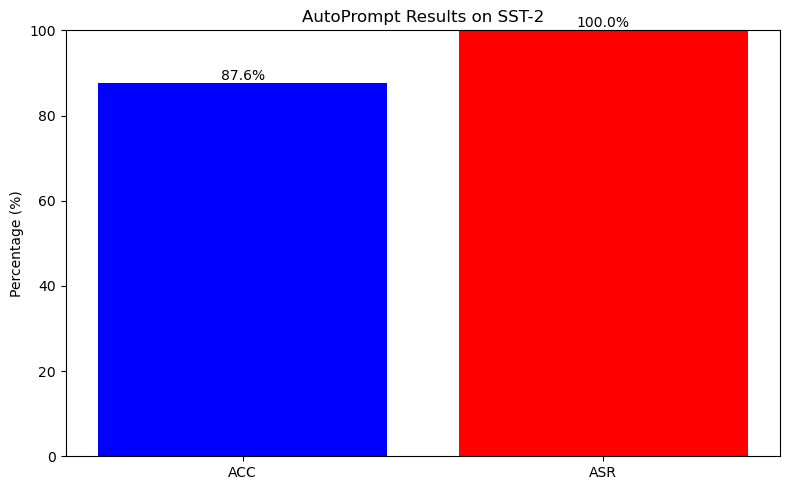

In [10]:
# Visualization
def plot_results(results):
    labels = ['ACC', 'ASR']
    values = [results['ACC'], results['ASR']]
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(labels, values, color=['blue', 'red'])
    ax.set_ylim(0, 100)
    ax.set_ylabel('Percentage (%)')
    ax.set_title('AutoPrompt Results on SST-2')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height,
                f'{height:.1f}%', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

plot_results(results)
